In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

#url = "https://old.reddit.com/r/Supplements/search?q=kachava&restrict_sr=on&sort=new"
#url = "https://old.reddit.com/r/nutrition/search?q=kachava&restrict_sr=on&sort=new"
url = "https://old.reddit.com/r/all/search?q=kachava&sort=new"
# Step 3: Headers
headers = {
    "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Step 4: GET Request
response = requests.get(url, headers=headers)
print("Status code:", response.status_code)

# Step 5: Parse HTML
if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")
    print("Page parsed successfully.")
else:
    print("Failed to retrieve page.")



# Step 6: Extract Thread Links from search results page
thread_links = []

# Search pages use 'search' not 'comments' for the event action
for tag in soup.find_all('a', attrs={'data-event-action': 'search'}):
    link = tag['href']
    if link.startswith('/'):
        link = 'https://old.reddit.com' + link
    thread_links.append(link)
    print(link)

# If still 0, try finding links differently
if len(thread_links) == 0:
    print("Trying alternative method...")
    for tag in soup.find_all('a', class_='search-title'):
        link = tag['href']
        if link.startswith('/'):
            link = 'https://old.reddit.com' + link
        thread_links.append(link)
        print(link)

print(f'\nTotal threads found: {len(thread_links)}')

# Step 7: Initialize Data Storage
threads_data = []

# Step 8: Extract Data from Each Thread
for i, link in enumerate(thread_links, start=1):
    print(f"Scraping thread {i}/{len(thread_links)}: {link}")

    try:
        thread_response = requests.get(link, headers=headers)

        if thread_response.status_code != 200:
            print(f"  -> Failed (status {thread_response.status_code}), skipping.")
            continue

        thread_soup = BeautifulSoup(thread_response.text, "html.parser")

        # Title
        title_tag = thread_soup.find("a", class_="title")
        title = title_tag.get_text(strip=True) if title_tag else "N/A"

        # Content
        content_tag = thread_soup.find("div", class_="expando")
        content = content_tag.get_text(separator=" ", strip=True) if content_tag else "N/A"

        # Comments
        comments_tag = thread_soup.find("a", attrs={"data-event-action": "comments"})
        if comments_tag:
            comments_text = comments_tag.get_text(strip=True)
            comments = comments_text.split()[0] if comments_text else "0"
        else:
            comments = "0"

        # Upvotes
        upvotes_tag = (
            thread_soup.find("div", class_="score unvoted") or
            thread_soup.find("div", class_="score likes")
        )
        upvotes = upvotes_tag.get_text(strip=True) if upvotes_tag else "N/A"

        # Posted Date
        time_tag = thread_soup.find("time")
        posted_date = time_tag["datetime"] if time_tag and time_tag.has_attr("datetime") else "N/A"

        # Append to list
        threads_data.append({
            "Title":       title,
            "Content":     content,
            "Comments":    comments,
            "Upvotes":     upvotes,
            "Posted Date": posted_date,
            "URL":         link
        })

        print(f"  -> OK: {title[:60]}...")
        time.sleep(2)

    except Exception as e:
        print(f"  -> Error: {e}")

print(f"\nDone. {len(threads_data)} threads scraped successfully.")

# Step 9: Convert to DataFrame
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

df = pd.DataFrame(threads_data)
print(df.shape)
df

Status code: 200
Page parsed successfully.
Trying alternative method...
https://old.reddit.com/r/KaChava/
https://old.reddit.com/user/KaChava/
https://old.reddit.com/r/Breakfast/comments/1tq6gb4/morning_breakfast_drink_meal/
https://old.reddit.com/r/SIBO/comments/1tptc0o/kachava/
https://old.reddit.com/r/veganfitness/comments/1tj6wvd/objective_protein_powder_comparison/
https://old.reddit.com/r/lolli/comments/1tiu43k/swipe_your_card_and_stack_sats_up_to_144_back_at/
https://old.reddit.com/r/purplecarrot/comments/1thhn9n/the_16_smoothie_and_the_open_question_where_the/
https://old.reddit.com/r/astoria/comments/1tagdlb/lost_kachava/
https://old.reddit.com/r/veganfitness/comments/1t3t3qy/is_kachava_protein_powder_really_that/
https://old.reddit.com/user/sprodoe/comments/1t3pjs3/may_2026_discount_codes_thc_drinks_cbd_gummies/
https://old.reddit.com/user/Mr_Rellim/comments/1t0sikg/may_2026_discount_codes_thc_drinks_cbd_gummies/
https://old.reddit.com/r/havens_jh/comments/1sull8k/cringe_whod

,Title,Content,Comments,Upvotes,Posted Date,URL
0,$15 off your first order if you want to give KaChava a try. :),loading...,32,13,2021-06-07T03:43:22+00:00,https://old.reddit.com/r/KaChava/
1,N/A,N/A,0,N/A,2020-08-07T22:21:57+00:00,https://old.reddit.com/user/KaChava/
2,Morning breakfast drink meal,,comment,1,2026-05-28T15:11:11+00:00,https://old.reddit.com/r/Breakfast/comments/1tq6gb4/morning_breakfast_drink_meal/
3,Ka'chava,"After I had diverticulitis, I turned to Kachava for liquid meals I could tolerate during my healing phase. I'm testing for SIBO this week, I'm pretty sure I have it. (I'm actually pretty sure I've had it for a long time, I have many of the symptoms and my doctor has been having me to test for it...",3,1,2026-05-28T04:44:29+00:00,https://old.reddit.com/r/SIBO/comments/1tptc0o/kachava/
4,Objective Protein Powder Comparison,"I’ve been looking for ways to get the most bang for my buck when it comes to vegan protein powders. I decided to take an hour of my day to watch paint dry and put together a list of brand comparisons to see which provides the most value. Here’s what I came up with, as an until I was exhausted (n...",9,13,2026-05-21T02:23:49+00:00,https://old.reddit.com/r/veganfitness/comments/1tj6wvd/objective_protein_powder_comparison/
5,"Swipe your card and stack sats — up to 14.4% back at Dropbox, Hydro Flask, Stanley, and dozens more with Lolli's card linked offers","Link a credit or debit card to Lolli, swipe it at participating merchants — online or in-store — and earn bitcoin cashback automatically. Here's what's live right now: Dropbox — 14.4% back Zenni Optical — 5.4% back Ka'Chava — 5.4% back Momentous — 5.4% back Hydro Flask — 3.6% back Smashburger — ...",comment,1,2026-05-20T18:18:48+00:00,https://old.reddit.com/r/lolli/comments/1tiu43k/swipe_your_card_and_stack_sats_up_to_144_back_at/
6,The $16 smoothie and the open question where the company is heading,"Seems there is a new type of item in the menu. However, seeing $16 smoothies I can't help but imagine Purple Carrot is set on outpricing its $11 customers. If you think about it, 10 days in and I can buy an ice cream Whynter machine (which I actually own one) and do my own out of cottage cheese ...",6,9,2026-05-19T09:29:46+00:00,https://old.reddit.com/r/purplecarrot/comments/1thhn9n/the_16_smoothie_and_the_open_question_where_the/
7,Lost Ka'Chava,If this is your building and you have my Ka'Chava I genuinely beg you to respond. This protein powder is not cheap - it was delivered on May 8th.,comment,6,2026-05-11T21:01:20+00:00,https://old.reddit.com/r/astoria/comments/1tagdlb/lost_kachava/
8,Is Ka'Chava protein powder really that evolutionary for it to be twice the price for half the amount of servings?,"I've always been curious about it, but I just can't get myself to fork over 80 smackers for a measly 15 servings, as I spend enough resources on protein, food, skin care, etc.. but I'm still curious and would like to know your honest take! Texture, flavor, digestibility, and overall comparison t...",22,9,2026-05-04T20:08:05+00:00,https://old.reddit.com/r/veganfitness/comments/1t3t3qy/is_kachava_protein_powder_really_that/
9,"May 2026 Discount Codes: THC Drinks, CBD Gummies, Skincare, Wellness, and Premium Lifestyle Brands such as Cann, Wims, Cuts Clothing, Ten Thousand, Grove, Ritual, Caraway and more — All Verified and Active","Updated for May 2026. Every code on this list is verified and active right now. I test and track over 60 direct-to-consumer brands across THC beverages, CBD products, men's and women's skincare, hair care, supplements, non-alcoholic drinks, premium food, home goods, and clothing. This monthly ro...",comment,2,2026-05-04T18:04:32+00:00,https://old.reddit.com/user/sprodoe/comments/1t3pjs3/may_2026_discount_codes_thc_drinks_cbd_gummies/


In [9]:
# Sentiment Analysis for Kachava
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if text == 'N/A' or not text or text == 'loading...':
        return 'N/A'
    score = analyzer.polarity_scores(text)
    if score['compound'] >= 0.05:
        return 'Positive'
    elif score['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Content'].apply(get_sentiment)
print("Kachava Sentiment Distribution:")
print(df['Sentiment'].value_counts())

Kachava Sentiment Distribution:
Sentiment
Positive    17
N/A          4
Neutral      2
Negative     1
Name: count, dtype: int64


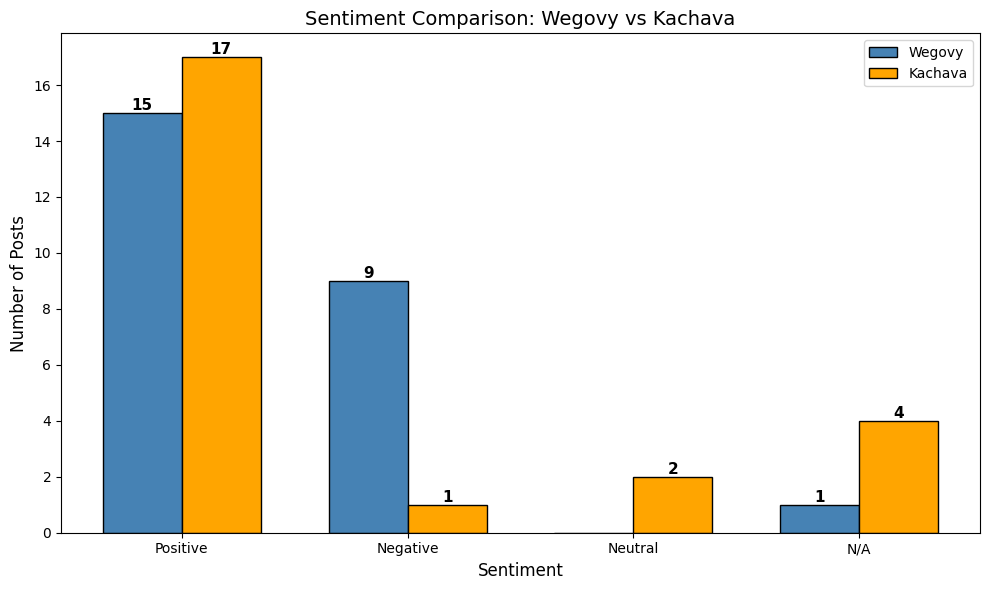

In [10]:
# Side by side comparison
import matplotlib.pyplot as plt
import numpy as np

# Wegovy numbers from earlier
wegovy_sentiment = {'Positive': 15, 'Negative': 9, 'N/A': 1}

# Kachava numbers
kachava_sentiment = df['Sentiment'].value_counts().to_dict()

# All categories
categories = ['Positive', 'Negative', 'Neutral', 'N/A']
wegovy_vals  = [wegovy_sentiment.get(c, 0) for c in categories]
kachava_vals = [kachava_sentiment.get(c, 0) for c in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, wegovy_vals,  width, label='Wegovy',  color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, kachava_vals, width, label='Kachava', color='orange',    edgecolor='black')

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.1,
                str(int(height)), ha='center', fontsize=11, fontweight='bold')

ax.set_title('Sentiment Comparison: Wegovy vs Kachava', fontsize=14)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Posts', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()
